# <u>Hamiltonian Simulation of the Transverse-Field Ising Model</u>

This notebook is an extension of a university exercise. We will study the dynamics of the one-dimensional transverse-field Ising model using quantum-circuit simulation methods. The Transverse Ising model is a simple quantum many-body problem. It contains:

1. interactions between neighboring spins
2. a transverse external field that tends to rotate the spins

We can write the Hamiltonian as a chain of particles that we will treat as qubits, with periodic boundary conditions, meaning that the final spin is coupled back to the first spin (ring not open chain):

$\begin{equation} H = -J \sum_i Z_iZ_{i+1} -h\sum_i X_i \end{equation}$


### <u>Physical interpretation</u>

The Hamiltonian contains two contributions. The interaction term is

$\begin{align}  H_{ZZ} = -J\sum_i Z_iZ_{i+1}\end{align}$

This term couples two neighboring spins. For J>0, the minus sign favors configurations in which neighboring spins are aligned in the computational basis. For example,

$$ |00\rangle\quad\text{and}\quad|11\rangle $$

have lower interaction energy than

$$ |01\rangle\quad\text{and}\quad|10\rangle $$

The second contribution,

$\begin{align} H_X = -h \sum_i X_i \end{align}$

describes a transverse field acting in the x-direction. The Pauli-X operator flips computational-basis states,

$$X|0\rangle = |1\rangle \qquad X|1\rangle = |0\rangle$$

The transverse field drives transitions between different spin configurations.

The two parts of the Hamiltonian compete with each other:

- the \(ZZ\) interaction favors alignment of neighboring spins,
- the \(X\) field tends to rotate and flip individual spins.

$H_{ZZ}$ and $H_X$ do not commute, so the time evolution cannot be written exactly as 

$\begin{align} U(t)=e^{-iHt} \neq e^{-iH_{ZZ}t} e^{-iH_Xt} \end{align}$

In the following we will look at different ways of approximating this.

### <u>Goal of this project</u>

For small systems, we can compute the exact evolution

$\begin{align}
|\psi(t)\rangle = e^{-iHt}|\psi(0)\rangle
\end{align}$

classically and use it as a reference.

We then compare this exact evolution with:

- first-order Lie-Trotter simulation,
- second-order Suzuki-Trotter simulation,
- and later randomized qDRIFT simulation.

The methods will be compared in terms of both simulation accuracy and quantum-circuit resources.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import expm
from qiskit.quantum_info import Statevector

from hamiltonian_simulation.ising import ising_hamiltonian
from hamiltonian_simulation.trotter import (first_trotterization, second_trotterization)

We start with a benchmark. Let us take a chain of 4 qubits, with a coupling J=1 and h=0.5. We will simulate the evolution up to t=2. First the Hamiltonian can be written as a string of Pauli matrices. The time evolution operator can be written classically for small times:

$$ \ket{\psi(t)} = e^{-iHt}\ket{\psi(t=0)} \,\,\,\, and\,\,\,\, \ket{\psi(0)} = \ket{0000} $$

In [5]:
N = 4
J = 1.0
h = 0.5
t = 2.0

H = ising_hamiltonian(J, h, N)

print(H)

SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'ZIIZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],
              coeffs=[-1. +0.j, -1. +0.j, -1. +0.j, -1. +0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
 -0.5+0.j])


In [6]:
psi0 = Statevector.from_label("0"*N)

H_mat = H.to_matrix()
U = expm(-1j*H_mat*t)

psi_t = U @ psi0.data

## Trotterized evolution

We now approximate the same evolution using first- and second-order product formulas. These arise as hinted at earlier due to $H_{ZZ}$ and $H_X$ not commuting, so we cannot simply write the exponential as a product of two exponentials.

For a time step

$$
\Delta t = \frac{t}{n_{\mathrm{steps}}},
$$

the first-order approximation is exactly the splitting into two parts. The idea is to do this for n steps, which leads to a chain of these exponentials:

$$
e^{-iH\Delta t}
\approx
e^{-iH_{ZZ}\Delta t}
e^{-iH_X\Delta t},
$$

I will skip the derivation for the second-order formula but it can be written as follows:

$$
e^{-iH\Delta t}
\approx
e^{-iH_{ZZ}\Delta t/2}
e^{-iH_X\Delta t}
e^{-iH_{ZZ}\Delta t/2}.
$$

For the trotterization, we will compare the time evolutions of 

$$ \ket{\psi(t)}_{trot1} = U_{trot1}(t)\ket{\psi(0)} \,\,\,\, and \,\,\,\,  \ket{\psi(t)}_{trot2} = U_{trot2}(t)\ket{\psi(0)} $$

With the exact time evolution. To compare these we will introduce the fidelity, which is a measure of overlap between the two states. This is written as $F_{12}= |\braket{ \psi_1 \psi_2}|^2$, where $F=1$ means the states are the same. I will use the infidelity $1-F$ as this is more easily interpreted as an error measurement

In [7]:
n_steps = 10

first_trotter = first_trotterization(J, h, n_qubits=N, t=t, n_steps=n_steps)
second_trotter = second_trotterization(J, h, n_qubits=N, t=t, n_steps=n_steps)

#Evolve the initial states using the trotter time evolutions
psi_first = psi0.evolve(first_trotter)
psi_second = psi0.evolve(second_trotter)

In [8]:
def infidelity(exactpsi, approxpsi):
    overlap = np.vdot(exactpsi, approxpsi)
    return 1-np.abs(overlap)**2

infidelity_first = infidelity(psi_t, psi_first.data)
infidelity_second = infidelity(psi_t, psi_second.data)

print("Infidelity of first order Trotterization: ", infidelity_first)
print("Infidelity of second order Trotterization: ", infidelity_second)

Infidelity of first order Trotterization:  0.018258672862589087
Infidelity of second order Trotterization:  0.0002462676687751131


## Convergence behaviour depending on trotter steps

Now it only makes sense to look at the behaviour of each approximation as we increase/decrease the number of trotter steps while keeping the time interval the same. Both of the approximations should approach the exact state and we will use the infidelity to see how accurately they reproduce the exact state.


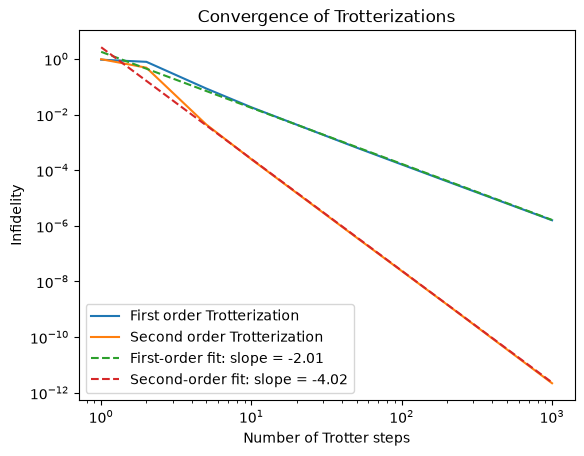

In [9]:
step_num = [1, 2, 5, 10, 50, 100, 200, 1000]

first_error =[]
second_error = []

for n_steps in step_num:
    first_trotter = first_trotterization(J,h, n_qubits=N, t=t, n_steps=n_steps)
    second_trotter = second_trotterization(J,h, n_qubits=N, t=t, n_steps=n_steps)

    psi_first = psi0.evolve(first_trotter)
    psi_second = psi0.evolve(second_trotter)

    first_error.append(infidelity(psi_t, psi_first.data))
    second_error.append(infidelity(psi_t, psi_second.data))

#Creating a line of best fit for the log-log plot
log_steps = np.log(step_num)

log_first_errors = np.log(first_error)
log_second_errors = np.log(second_error)

slope_first, intercept_first = np.polyfit(log_steps, log_first_errors, 1)
slope_second, intercept_second = np.polyfit(log_steps, log_second_errors, 1)

fit_first = np.exp(intercept_first) * np.array(step_num) ** slope_first
fit_second = np.exp(intercept_second) * np.array(step_num) ** slope_second


plt.loglog(step_num, first_error, label= 'First order Trotterization')
plt.loglog(step_num, second_error, label = 'Second order Trotterization')
plt.loglog(step_num, fit_first, "--", label=f"First-order fit: slope = {slope_first:.2f}")
plt.loglog(step_num, fit_second, "--", label=f"Second-order fit: slope = {slope_second:.2f}")
plt.xlabel('Number of Trotter steps')
plt.ylabel('Infidelity')
plt.title('Convergence of Trotterizations')
plt.legend()
plt.show()

I used logarithmic axes as it makes the power-law relation apparent and on this scale the gradient roughly translates to the exponent. By this I mean that we can roughly see a $n^{-2}$ and $n^{-4}$ relation. Since the infidelity is quadratic in state-vector error, this is an error of order

$$ \epsilon \propto O(\Delta t) $$
And for 2nd order:
$$ \epsilon \propto O(\Delta t^2) $$


## Accuracy vs Circuit Cost

We have compared accuracy versus step count, but this is not the best comparison practically, as for the 2nd Troterrization we need more gates per step than the first. Here I will look into accuracy vs circuit cost. A key difference is the number of RZZ gates. For an N-qubit chain in first order we have
$$N\, \text{number of RZZ gates}$$ while in 2nd order we have $$2N\,\text{ number of RZZ gates}$$ per step. The number of X gates grows linearly in both regimes, i.e. it has the same per step scaling, so it is more interesting to single out the RZZ gate.

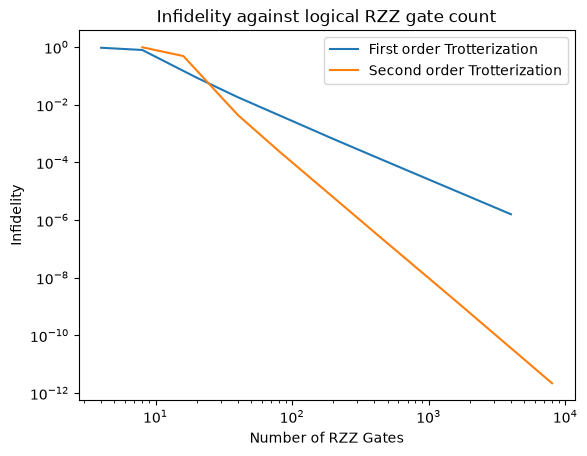

In [10]:
first_rzz_count = []
second_rzz_count = []

for n_steps in step_num:
    first_trotter = first_trotterization(J,h, n_qubits=N, t=t, n_steps=n_steps )
    second_trotter = second_trotterization(J,h, n_qubits=N, t=t, n_steps=n_steps)

    first_rzz_count.append(first_trotter.count_ops().get('rzz', 0))
    second_rzz_count.append(second_trotter.count_ops().get('rzz', 0))

plt.loglog(first_rzz_count, first_error, label='First order Trotterization')
plt.loglog(second_rzz_count, second_error, label='Second order Trotterization')
plt.xlabel('Number of RZZ Gates')
plt.ylabel('Infidelity')
plt.title('Infidelity against logical RZZ gate count')
plt.legend()    
plt.show()

RZZ is a logic two-qubit gate and not necessarily a hardware-gate. I'll use a fake IBM backend to test transpilation of the circuit into the native gate set, to estimate the needed resources.

In [11]:
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

backend = FakeSherbrooke()

In [12]:
#I set the seed to 1 for reproducibility of the transpilation results
seed =1
n_steps_hardware = 10

qc_first = first_trotterization( J, h, N, t, n_steps_hardware)
qc_second = second_trotterization(J, h, N, t, n_steps_hardware)

qc_first_transpiled = transpile(qc_first, backend=backend, optimization_level=3, seed_transpiler = seed)
qc_second_transpiled = transpile(qc_second, backend=backend, optimization_level=3, seed_transpiler = seed)

print("First order:")
print(qc_first_transpiled.count_ops())
print("Depth:", qc_first_transpiled.depth())

print()

print("Second order:")
print(qc_second_transpiled.count_ops())
print("Depth:", qc_second_transpiled.depth())


First order:
OrderedDict([('rz', 524), ('sx', 335), ('ecr', 137), ('x', 10)])
Depth: 683

Second order:
OrderedDict([('rz', 1037), ('sx', 641), ('ecr', 277), ('x', 64)])
Depth: 1379


We will now compare number of native two-qubits gates* and the transpiled circuit depth with the state infidelity of the corresponding Trotter approximation, to determine which method is more cost effective. No noise from the physical gates will be taken into account and they will be seen as ideal gates.

*We will specifically count the ecr gate as this is the two-qubit gate in question. The two qubit gates are usually the more noisy and costly ones, which is why I am singling these out.

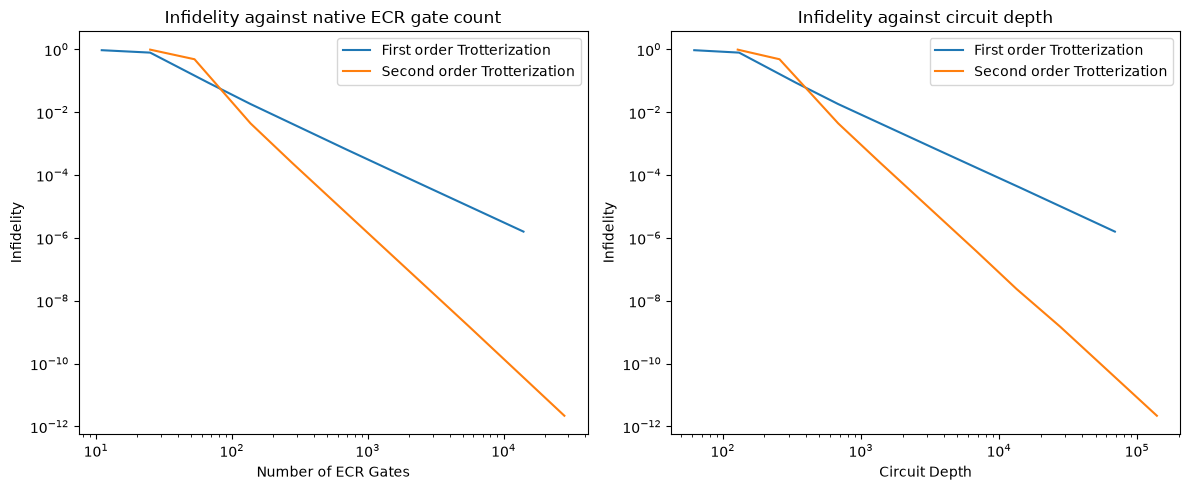

In [13]:
first_ecr_count =[]
second_ecr_count = []

first_depth_count =[]
second_depth_count = []

for n_steps in step_num:
    first_trotter = first_trotterization(J,h, n_qubits=N, t=t, n_steps = n_steps)
    second_trotter = second_trotterization(J,h, n_qubits = N, t=t, n_steps=n_steps)

    first_trot_transpiled = transpile(first_trotter, backend = backend, optimization_level = 3, seed_transpiler = seed)
    second_trot_transpiled = transpile(second_trotter, backend = backend, optimization_level=3, seed_transpiler = seed)

    first_ecr_count.append(first_trot_transpiled.count_ops().get('ecr',0))
    second_ecr_count.append(second_trot_transpiled.count_ops().get('ecr',0))

    first_depth_count.append(first_trot_transpiled.depth())
    second_depth_count.append(second_trot_transpiled.depth())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].loglog(first_ecr_count, first_error, label='First order Trotterization')
ax[0].loglog(second_ecr_count, second_error, label='Second order Trotterization')
ax[0].set_xlabel('Number of ECR Gates')
ax[0].set_ylabel('Infidelity')
ax[0].legend()
ax[0].set_title('Infidelity against native ECR gate count')


ax[1].loglog(first_depth_count, first_error, label='First order Trotterization')
ax[1].loglog(second_depth_count, second_error, label='Second order Trotterization')
ax[1].set_xlabel('Circuit Depth')
ax[1].set_ylabel('Infidelity')
ax[1].legend()
ax[1].set_title('Infidelity against circuit depth')

plt.tight_layout()
plt.show()

For the parameter regime we are studying here, at small budgets, first order trotterization is more cost effective. At about $10^2$ gates, it switches as the 2nd trotterization has a much faster convergence, and the 2nd trotter approach becomes more cost effective.

## <u>qDrift</u>

qDrift is a stochastic approximation of Hamiltonians. Here we treat a Hamiltonian as a sum of coefficients and Pauli strings and assign probabilistic weights to them.
$$ H = \sum_i h_i P_i \qquad \lambda=\sum_j |h_j| \qquad p_j=\frac{|h_j|}{\lambda} $$
The algorithm then picks a term in the Hamiltonian at random based on the probabilities and lets that term's time evolution operator act on the state. This is then done r times.
$$ U_j = e^{-i sgn(h_j) \frac{\lambda t}{r}P_j} \qquad \tau = \frac{\lambda t}{r} \qquad U_{qDrift}=U_{j_r} ... U_{j_1} $$
In the following, we will look at the same metrics as we did for the trotterization approach and compare qDRIFT. A key difference here is the stochasticity of qdrift. We will average over many seeds to find mean values for the qdrift approach as well as errors.

In [14]:
from qiskit.quantum_info import SparsePauliOp
from hamiltonian_simulation.qdrift import qDrift

In [15]:
qd_error = []
qd_std_dev = []

step_qd = [1, 5, 100, 400, 1000, 10000,40000]
for r in step_qd:

    error_per_r = []

    #average for 50 different seeds
    for seed in range(50):

        qc_qdrift = qDrift(H, r, t, seed)
        psi_q = psi0.evolve(qc_qdrift)

        inf = infidelity(psi_t, psi_q)
        error_per_r.append(inf)

    avg_error_per_step = np.mean(error_per_r)
    qd_error.append(avg_error_per_step)

    std_dev_per_step = np.std(error_per_r)
    qd_std_dev.append(std_dev_per_step)


The slope of the qDrift approach: -0.9787850830439845


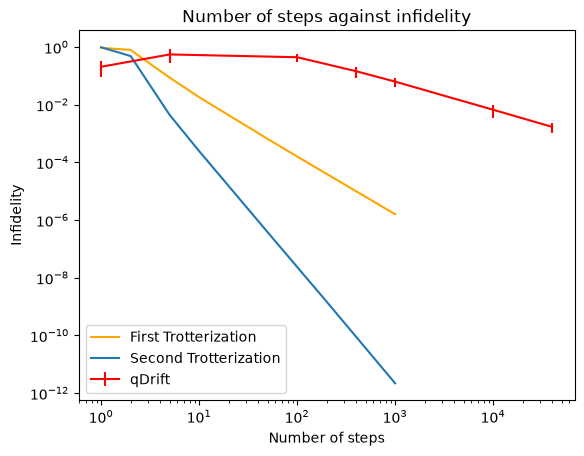

In [16]:
#find the slope of qdrift
log_r = np.log(step_qd)
log_error = np.log(qd_error)

slope_qd, intercept_qd = np.polyfit(log_r[-3:], log_error[-3:], 1)

print("The slope of the qDrift approach:", slope_qd)

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel('Number of steps')
ax.set_ylabel('Infidelity')
ax.set_title('Number of steps against infidelity')

ax.errorbar(step_qd, qd_error, yerr= qd_std_dev, label = 'qDrift', color = 'red')
ax.plot(step_num, first_error, label = 'First Trotterization', color = 'orange')
ax.plot(step_num, second_error, label = 'Second Trotterization')
ax.legend()

plt.show()

The fitted qDRIFT slope is approximately $m=-0.98$, which is consistent with an inverse r-scaling of the mean infidelity.

### Accuracy vs circuit cost for the qDrift approach

The last thing I will cover in this notebook is the hardware cost for the qDrift algorithm. We will do the same calculation we did for the trotterization and compare to qDrift.

In [17]:
qd_ecr_count = []
qd_ecr_count_std_dev = []
qd_depth = []
qd_depth_std_dev=[]

#I will average over many different qDrift seeds, but will keep the transpiler seed fixed
transp_seed = 1

for r in step_qd:
    ecr_per_r = []
    ecr_per_r_std =[]
    depth_per_r = []
    depth_per_r_std =[]

    for seed in range(50):
        qd_c = qDrift(H, r, t, seed)

        qd_transpiled = transpile(qd_c, backend= backend, optimization_level=3, seed_transpiler = transp_seed)
        ecr_per_r.append(qd_transpiled.count_ops().get('ecr',0))
        depth_per_r.append(qd_transpiled.depth())

    qd_ecr_count.append(np.mean(ecr_per_r))
    qd_ecr_count_std_dev.append(np.std(ecr_per_r))
    qd_depth.append(np.mean(depth_per_r))
    qd_depth_std_dev.append(np.std(depth_per_r))

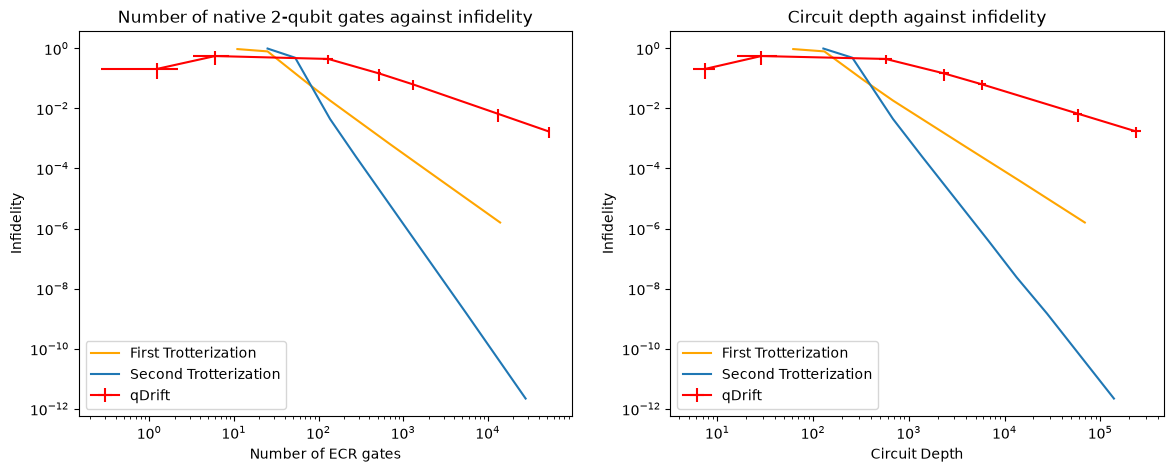

In [18]:
fig, ax = plt.subplots(1,2, figsize = (14, 5))

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Number of ECR gates')
ax[0].set_ylabel('Infidelity')
ax[0].set_title('Number of native 2-qubit gates against infidelity')
ax[0].errorbar(qd_ecr_count, qd_error, xerr= qd_ecr_count_std_dev, yerr = qd_std_dev, label = 'qDrift', color = 'red')
ax[0].plot(first_ecr_count,first_error,  label = 'First Trotterization', color = 'orange')
ax[0].plot(second_ecr_count,second_error,  label = 'Second Trotterization')
ax[0].legend()

ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('Circuit Depth')
ax[1].set_ylabel('Infidelity')
ax[1].set_title('Circuit depth against infidelity')
ax[1].errorbar(qd_depth, qd_error, xerr= qd_depth_std_dev, yerr = qd_std_dev, label = 'qDrift', color = 'red')
ax[1].plot(first_depth_count,first_error,  label = 'First Trotterization', color = 'orange')
ax[1].plot(second_depth_count,second_error,  label = 'Second Trotterization')
ax[1].legend()

plt.show()

### Conclusion

For the transverse-Ising Hamiltonian studied here, the trotterization method is the appropriate method to use, as it performs better per step, but more importantly per native 2-qubit gate and circuit depth. Here the 2nd trotterization would be the most cost-effective method to use. The qdrift circuit requires many more gates to reach the same infideltiy levels as the other approaches. This is only valid for the parameters used here, ie the backend, Hamiltonian and time steps. For other Hamiltonians with different coupling distributions, this could look very different and I will study this in another notebook.